$$
\begin{aligned}
\dot{R} & = -\alpha \sqrt{\frac{2GM}{R}} \\
\frac{dR}{dt} & = -\alpha \sqrt{\frac{2GM}{R}} \\
\int \sqrt{R}\; dR & = - \int \alpha \sqrt{2 GM}\; dt \\ 
\frac{2}{3}R^{3/2} & = - \alpha t \sqrt{2 GM} + C \\
\frac{4}{9} R^3 & = 2\alpha^2 t^2 GM \\
R(t) & = \sqrt[3]{\frac{9}{2}\alpha^2 t^2 GM}
\end{aligned}
$$

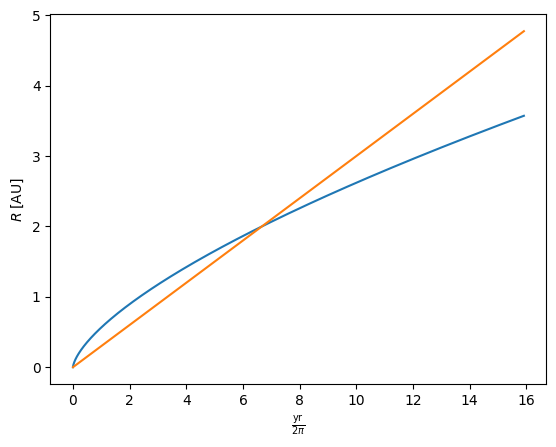

In [1]:
import numpy as np
import matplotlib.pyplot as plt
t0 = 1/(2 * np.pi)
alpha = 0.2
cs = np.sqrt(3.36)*100
R = lambda t : ((9/2) * alpha**2 * t**2)**(1/3)
t = np.geomspace(1e-6 * t0, 100 * t0, 1000)
plt.plot(t, R(t))
plt.plot(t, 0.3*t)
plt.ylabel(r"$R\; [\mathrm{AU}]$")
plt.xlabel(r"$\frac{\mathrm{yr}}{2\pi}$")
plt.show()

Now, consider a cloud of constant density within $R(t)$, 

$$
\rho(r) = \rho_0
$$

So, if we say that for $ r = R $, the enclosed mass is $M_\odot$, 

$$
\begin{aligned}
M_\odot & = \rho_0 V \\
M_\odot & = \rho_0 \frac{4}{3} \pi R^3 \\
\rho(r \le R) & = \frac{3 M_\odot}{4 \pi R^3}
\end{aligned}
$$

So, we have 

$$
\begin{aligned}
\rho(r,t) = 
\begin{cases}
\frac{3 M_\odot}{4 \pi R^3} & r \le R \\
0 & r > R \\
\end{cases}
\end{aligned}
$$


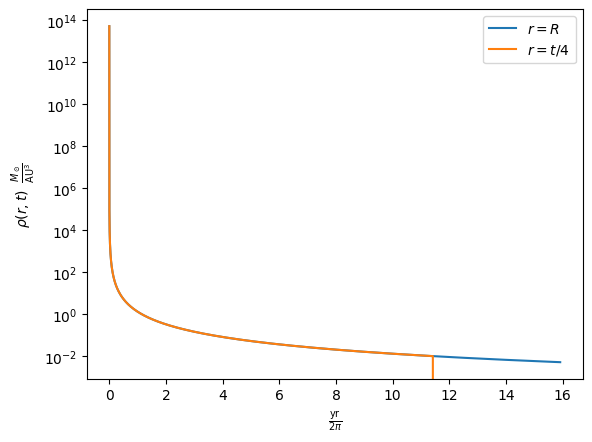

In [2]:
rho = lambda r, tp: np.where((r >= 0) & (r <= R(tp)), 3 / (4 * np.pi * R(tp)**3), 0.0)
r = lambda tp : tp/4
plt.plot(t,rho(R(t),t), label = r"$r = R$")
plt.plot(t, rho(r(t),t),label = r"$r = t/4$")
plt.yscale("log")
plt.legend()
plt.xlabel(r"$\frac{\mathrm{yr}}{2\pi}$")
plt.ylabel(r"$\rho(r,t)\;\; \frac{M_\odot}{\mathrm{AU}^3}$")
plt.show()

So, for our enclosed mass, we have 

$$
\begin{aligned}
M(r,t) & = \int \rho(r,t)\; dV \\
& = 4\pi \int \rho(r',t) r'^2 \; dr' \\
 & = 4\pi\int_0^R \frac{3 M_\odot}{4 \pi R^3} r'^2 \; dr'\\
 & = M_\odot
\end{aligned}
$$

As expected. So, for $r < R$, we will integrate $\rho(r,t)$ from $0$ to $r$, resulting in 

$$
M(r,t) =
\begin{cases}
M_\odot & r \ge R \\
M_\odot \left(\frac{r}{R}\right)^3 & r < R \\
\end{cases}
$$


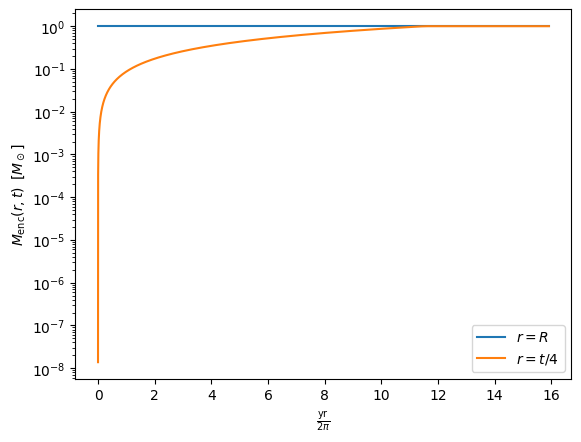

In [3]:
M_enc = lambda r, tp: np.where(r < R(tp), (r / R(tp))**3, 1.0)
plt.plot(t,M_enc(R(t),t), label = r"$r = R$")
plt.plot(t, M_enc(r(t),t),label = r"$r = t/4$")
plt.yscale("log")
plt.legend()
plt.xlabel(r"$\frac{\mathrm{yr}}{2\pi}$")
plt.ylabel(r"$M_{\rm enc}(r,t)\;\; \left[M_\odot\right]$")
plt.show()

Now, for $\varphi(r,t)$, we begin with Poisson's equation,

\begin{align}
    \nabla^2\varphi &= 4\pi G\rho.
\end{align}

Using the divergence theorem, we have

\begin{align}
    \oint_S \vec{\nabla}\varphi\cdot d\vec{S}
    &= \int_V \nabla^2\varphi\;dV\\
    &= 4\pi G\int_V\rho\;dV\\
    &= 4\pi G M(<r,t).
\end{align}

For a spherically symmetric potential,

\begin{align}
    \vec{\nabla}\varphi
    &= \frac{\partial\varphi}{\partial r}\hat{r},
\end{align}

and the outward-pointing surface element is

\begin{align}
    d\vec{S}
    &= \hat{r}\,r^2\sin\theta\;d\theta\,d\phi.
\end{align}

Therefore,

\begin{align}
    \oint_S\vec{\nabla}\varphi\cdot d\vec{S}
    &=
    \frac{\partial\varphi}{\partial r}
    r^2
    \int_0^{2\pi}d\phi
    \int_0^\pi\sin\theta\;d\theta\\
    &=4\pi r^2\frac{\partial\varphi}{\partial r}.
\end{align}

Equating the two expressions gives

\begin{align}
    4\pi r^2\frac{\partial\varphi}{\partial r}
    &=4\pi G M(<r,t),
\end{align}

so

\begin{align}
    \frac{\partial\varphi}{\partial r}
    &=\frac{GM(<r,t)}{r^2}.
\end{align}

The enclosed mass is

\begin{align}
    M(<r,t)
    &=4\pi\int_0^r\rho(r',t)r'^2\;dr'.
\end{align}

It follows that

\begin{align}
    \frac{\partial\varphi}{\partial r}
    &=
    \frac{4\pi G}{r^2}
    \int_0^r\rho(r',t)r'^2\;dr'.
\end{align}

Taking $\varphi(\infty,t)=0$, we integrate from $r$ to infinity:

\begin{align}
    \varphi(\infty,t)-\varphi(r,t)
    &=
    \int_r^\infty
    \frac{\partial\varphi}{\partial r'}\;dr',
\end{align}

and therefore

\begin{align}
    \varphi(r,t)
    &=
    -4\pi G
    \int_r^\infty
    \frac{dr'}{r'^2}
    \int_0^{r'}
    \rho(r'',t)r''^2\;dr''.
\end{align}

To reverse the order of integration, we divide the integration
region into two parts. For $0\leq r''\leq r$, the coordinate $r'$
ranges from $r$ to infinity. For $r''\geq r$, the coordinate $r'$
ranges from $r''$ to infinity. Thus,

\begin{align}
    \varphi(r,t)
    =-4\pi G\Bigg[
    &\int_0^r
    \rho(r'',t)r''^2
    \left(
    \int_r^\infty\frac{dr'}{r'^2}
    \right)dr''
    \nonumber\\
    +{}&
    \int_r^\infty
    \rho(r'',t)r''^2
    \left(
    \int_{r''}^\infty\frac{dr'}{r'^2}
    \right)dr''
    \Bigg].
\end{align}

The inner integrals are

\begin{align}
    \int_r^\infty\frac{dr'}{r'^2}
    &=\frac{1}{r},
    &
    \int_{r''}^\infty\frac{dr'}{r'^2}
    &=\frac{1}{r''}.
\end{align}

Therefore,

\begin{align}
    \varphi(r,t)
    =
    -4\pi G
    \left[
    \frac{1}{r}
    \int_0^r\rho(r',t)r'^2\;dr'
    +
    \int_r^\infty\rho(r',t)r'\;dr'
    \right]
\end{align}

So, for our 

$$
\begin{aligned}
\rho(r,t) = 
\begin{cases}
\frac{3 M_\odot}{4 \pi R^3} & r \le R \\
0 & r > R \\
\end{cases}
\end{aligned}
$$

Consider the $r \ge R$ case; then the second integral becomes zero, and we have

\begin{align}
    \varphi(r \ge R,t)
    & =
    -\frac{4\pi G}{r}
    \int_0^R\rho(r',t)r'^2\;dr' \\
    & = -\frac{4\pi G}{r}
    \frac{3 M_\odot}{4 \pi R^3}\int_0^Rr'^2\;dr' \\
    & = - \frac{GM_\odot}{r}
\end{align}




Then, for particles interior to the cloud, $r < R$,

\begin{align}
    \varphi(r,t)
    & =
    -4\pi G
    \left[
    \frac{1}{r}
    \int_0^r\rho(r',t)r'^2\;dr'
    +
    \int_r^R\rho(r',t)r'\;dr'
    \right] \\
    & = -4 \pi G \frac{3 M_\odot}{4 \pi R^3} \left[
    \frac{1}{r}
    \int_0^rr'^2\;dr'
    +
    \int_r^Rr'\;dr'
    \right] \\
    & = - \frac{3 GM_\odot}{R^3}\left[\frac{r^2}{3}+\frac{R^2}{2}-\frac{r^2}{2}\right] \\
    & = -\frac{GM_\odot}{2 R}\left[3 - \left(\frac{r}{R}\right)^2\right]
\end{align}

Therefore, 

$$
\varphi(r,t) =
\begin{cases}
-\frac{GM_\odot}{2 R}\left[3 - \left(\frac{r}{R}\right)^2\right] & r < R \\
-\frac{GM_\odot}{r} & r \ge R \\
\end{cases}
$$


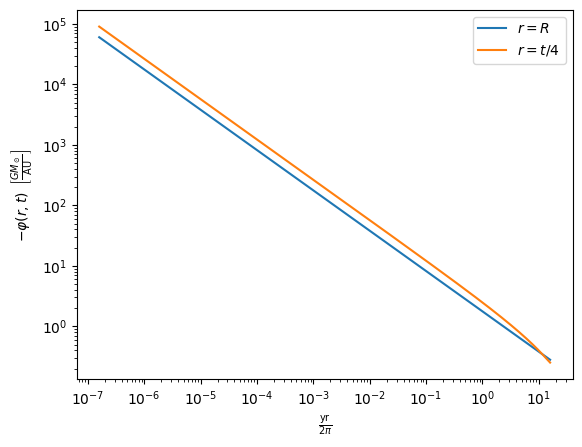

In [4]:
phi = lambda r, tp: np.where(r < R(tp), -(3 - (r / R(tp))**2) / (2 * R(tp)), -1 / r)
plt.plot(t, -phi(R(t),t), label = r"$r = R$")
plt.plot(t, -phi(r(t),t),label = r"$r = t/4$")
plt.yscale("log")
plt.xscale("log")
plt.legend()
plt.xlabel(r"$\frac{\mathrm{yr}}{2\pi}$")
plt.ylabel(r"$-\varphi(r,t)\;\; \left[\frac{G M_\odot}{\mathrm{AU}}\right]$")
plt.show()

Now, as we are considering the energy dynamics, the kinetic and potential energies satisfy

$$
\dot{E}_k = - \vec{v}\cdot\nabla\varphi
\qquad
\dot{E}_p = \vec{v}\cdot\nabla\varphi + \frac{\partial \varphi}{\partial t}
$$

Therefore,

$$
\frac{dE_{\rm tot}}{dt} = \frac{\partial \varphi}{\partial t}
$$

To compute $\frac{\partial \varphi}{\partial t}$, we use the chain rule to write

$$
\begin{aligned}
\frac{dE_{\rm tot}}{dt} & = \frac{\partial \phi}{\partial R}\frac{dR}{dt} \\
& = - \alpha \frac{\partial \phi}{\partial R}  \sqrt{\frac{2GM}{R}} \\
& = - \frac{3\alpha}{2} \sqrt{\frac{2\left(GM_\odot\right)^3}{R^5}}\left[1-\left(\frac{r}{R}\right)^2\right] \\
& = - \frac{3\alpha}{\sqrt{2}} \sqrt{\frac{\left(GM_\odot\right)^3}{R^5}}\left[1-\left(\frac{r}{R}\right)^2\right]
\end{aligned}
$$

Define the dimensionless radius and characteristic velocity as

\begin{align}
    x &\equiv \frac{r}{R_*},
    &
    v_*^2 &\equiv \frac{GM}{R_*}.
\end{align}

In the limit $v_0\ll v_*$, and assuming that the cloud radius remains
approximately equal to $R_*$ during the crossing, conservation of
energy in the instantaneous potential gives

\begin{align}
    v(r)^2
    &=v_0^2-2\varphi(r,R_*)\\
    &\simeq
    v_*^2\left(3-x^2\right).
\end{align}

Therefore,

\begin{align}
    v(r)\simeq v_*\sqrt{3-x^2}.
\end{align}

The magnitude of the explicit time derivative of the potential is

\begin{align}
    \left|
    \frac{\partial\varphi}{\partial t}
    \right|
    &=
    \frac{3\alpha}{\sqrt{2}}
    \frac{v_*^3}{R_*}
    \left(1-x^2\right).
\end{align}

The factor of two for the inward and outward portions of the
trajectory, together with the normalization
$E_i=v_0^2/2$, gives

\begin{align}
    \Delta\widetilde E
    &\equiv
    \frac{|\Delta E|}{E_i}\\
    &=
    \frac{4}{v_0^2}
    \int_0^{R_*}
    \frac{1}{v(r)}
    \left|
    \frac{\partial\varphi}{\partial t}
    \right|dr.
\end{align}

Using $r=R_*x$ and $dr=R_*dx$, we obtain

\begin{align}
    \Delta\widetilde E
    &=
    6\sqrt{2}\,\alpha
    \left(\frac{v_*}{v_0}\right)^2
    \int_0^1
    \frac{1-x^2}{\sqrt{3-x^2}}\,dx.
\end{align}

The remaining integral is

\begin{align}
    \int_0^1
    \frac{1-x^2}{\sqrt{3-x^2}}\,dx
    &=
    \frac{1}{\sqrt{2}}
    -\frac{1}{2}
    \sin^{-1}\left(\frac{1}{\sqrt{3}}\right).
\end{align}

Therefore,

\begin{align}
    \Delta\widetilde E
    &=
    \left[
    6-3\sqrt{2}
    \sin^{-1}\left(\frac{1}{\sqrt{3}}\right)
    \right]
    \alpha
    \left(\frac{v_*}{v_0}\right)^2\\
    &\approx
    3.39\,\alpha
    \left(\frac{v_*}{v_0}\right)^2.
\end{align}

Now, capture occurs when $\Delta \tilde{E} > 1$, 

$$
\begin{aligned}
\Delta\tilde{E} > 1 \\
3.39 \alpha \left(\frac{v_*}{v_0}\right)^2 > 1\\
3.39 \alpha \frac{GM_\odot}{v_0^2R} > 1
\end{aligned}
$$

Therefore, $R_{\rm max}$, the maximum radius for which a capture occurs is

$$
R_{\rm max} = 3.39 \alpha \frac{GM_\odot}{v_0^2}
$$


Conservation of energy leads to 

$$
\begin{aligned}
v(R)^2 & = v_0^2 + \frac{2GM}{R}
\end{aligned}
$$

and conservation of angular momentum gives

$$
\begin{aligned}
b v_0 & = R v(R)
\end{aligned}
$$

$$
b_{\rm max} = R \sqrt{1+\frac{2 GM_\odot}{v_0^2R}}
$$

and therefore, the capture cross section is

$$
\sigma_{\rm enc} = \pi R^2 \left(1+\frac{2 GM_\odot}{v_0^2R}\right)
$$

The encounter rate $\mathscr{R}(R)$ is given by 

$$
\mathscr{R}(R) = n_0 v_0 \sigma_{\rm enc}
$$

The number captured, $N_{\rm capt}$ satisfies

$$
\begin{aligned}
N_{\rm capt}(v_0) & = \int \mathscr{R}(R)\; dt \\
& = \int \frac{\mathscr{R}(R)}{\left|\dot{R}\right|}\; dR
\end{aligned}
$$

Now, define $R_{\rm lim} \equiv \min(R_{\rm max}, R_{\rm init})$, then 

\begin{align}
N_{\rm capt}(v_0) & = \frac{\pi n_0 v_0}{\alpha \sqrt{2 GM_\odot}} \int_0^{R_{\rm lim}} R^{5/2} \left(1 + \frac{2GM_\odot}{v_0^2R}\right)\; dR \\
& = \frac{\pi n_0 v_0}{\alpha} \sqrt{\frac{2}{GM_\odot}} R_{\rm lim}^{5/2}\left(\frac{R_{\rm lim}}{7}+\frac{2GM_\odot}{5v_0^2}\right)
\end{align}

If we consider the case $R_{\rm lim} = R_{\rm max}$, 

\begin{align}
N_{\rm capt}(v_0) & = \frac{\pi n_0}{\alpha}\sqrt{\frac{2 v_0^2}{GM_\odot}}\left(\frac{R_{\rm max}^{7/2}}{7}+\frac{2GM_\odot}{5v_0^2}R_{\rm max}^{5/2}\right) \\
& = \frac{\pi n_0}{\alpha}\sqrt{\frac{2 v_0^2}{GM_\odot}}\left(\frac{3.39^{7/2}\alpha^{7/2}}{7}\left(\frac{GM_\odot}{v_0^2}\right)^{7/2}+\frac{2\cdot 3.39^{5/2}}{5}\alpha^{5/2}\left(\frac{GM_\odot}{v_0^2}\right)^{7/2}\right) \\
& \approx n_0 \alpha^{3/2}\left(\frac{GM_\odot}{v_0^2}\right)^3\left(45.5 \alpha + 37.6\right)
\end{align}

So then, the capture volume is approximately 

\begin{align}
V_{\rm capt}(v_0) & \approx \alpha^{3/2}\left(\frac{GM_\odot}{v_0^2}\right)^3\left(45.5 \alpha + 37.6\right)
\end{align}

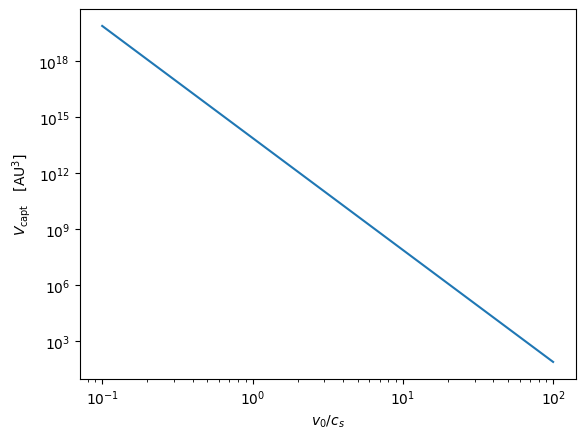

In [17]:
cs = 6.15e-3 #sqrt(3.36e4) in sqrt((GM)/AU) units
vvec = np.linspace(0.1*cs,100*cs,1000)
alpha = 0.2
Vcapt = lambda v: alpha**(3/2)/v**6*(45.5*alpha + 37.6)
plt.plot(vvec/cs, Vcapt(vvec))
plt.yscale("log")
plt.xscale("log")
plt.ylabel(r"$V_{\rm capt}\quad \left[\mathrm{AU}^3\right]$")
plt.xlabel(r"$v_0/c_s$")
plt.show()